# 07 - MapMyCells reference mapping

Cross-reference the nuclei against the Allen Institute **SEA-AD 10x Human MTG (CCN20230505)**
taxonomy, mapped with *Deep Generative Mapping* (`vae_cell_type_mapper_scvi` v2.0.2).

**This step is not reproducible from code alone.** `interim/mapmycells_raw_upload.h5ad` (raw
counts, cells x genes) is uploaded by hand to <https://knowledge.brain-map.org/mapmycells/process>
and the returned archive unpacked into `data/mapmycells/`. That CSV is committed to the
repository because it cannot be regenerated locally. The first cell rebuilds the upload file if
it is missing, so the submission can be repeated.

Questions
1. Do independent reference labels agree with the author cell-type calls?
2. Does the reference rescue the `unID` / `doublet` nuclei?
3. Which reference cell types carry the AD genetic risk signal?
4. Which microglial states are expanded in AD?

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
from adpipe import *

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, fisher_exact
from statsmodels.stats.multitest import multipletests

MMC_CSV = MAPMYCELLS / "mapmycells_SEAAD_MTG_deepgenerative.csv"
UPLOAD = INTERIM / "mapmycells_raw_upload.h5ad"
print("MapMyCells result present:", MMC_CSV.exists())

MapMyCells result present: True


In [2]:
# Rebuild the upload file if it is missing.  MapMyCells wants RAW counts, cells x genes.
if UPLOAD.exists():
    print(f"upload file already present ({UPLOAD.stat().st_size / 1e9:.2f} GB)")
else:
    src = sc.read_h5ad(INTERIM / "adata_lognorm.h5ad")
    upload = sc.AnnData(X=src.layers["counts"].copy())
    upload.obs_names, upload.var_names = src.obs_names, src.var_names
    upload.write(UPLOAD)
    print("wrote", UPLOAD, "- upload this to MapMyCells, then unpack the result "
          "into data/mapmycells/")
    del src, upload

upload file already present (1.15 GB)


In [3]:
with open(MMC_CSV) as fh:
    provenance = [next(fh).rstrip() for _ in range(3)]
print("\n".join(provenance))

mmc = pd.read_csv(MMC_CSV, comment="#", index_col=0)
print(f"\nmapped cells: {mmc.shape[0]:,}")
mmc.head(3)

# taxonomy hierarchy = ["CCN20230505_CLAS", "CCN20230505_SUBC", "CCN20230505_SUPT"]
# readable taxonomy hierarchy = ["class", "subclass", "supertype"]
# algorithm: 'Deep Generative Mapping'; codebase: https://github.com/AllenInstitute/vae_cell_type_mapper_scvi; version: 2.0.2

mapped cells: 13,214


,class_label,class_name,class_softmax_probability,subclass_label,subclass_name,subclass_softmax_probability,supertype_label,supertype_name,supertype_softmax_probability
cell_id,,,,,,,,,
AAACCTGGTAGAAAGG_AD5_AD6,CS20230505_CLAS_0003,Non-neuronal and Non-neural,1.0,CS20230505_SUBC_0021,Oligodendrocyte,1.0,CS20230505_SUPT_0121,Oligo_2,0.9999
AAACCTGGTAGCGATG_AD5_AD6,CS20230505_CLAS_0003,Non-neuronal and Non-neural,1.0,CS20230505_SUBC_0021,Oligodendrocyte,1.0,CS20230505_SUPT_0121,Oligo_2,1.0000
AAACCTGTCAGTCAGT_AD5_AD6,CS20230505_CLAS_0003,Non-neuronal and Non-neural,1.0,CS20230505_SUBC_0021,Oligodendrocyte,1.0,CS20230505_SUPT_0123,Oligo_4,0.9999


In [4]:
adata = sc.read_h5ad(INTERIM / "adata_clustered.h5ad")
obs = adata.obs.copy()

keep = ["class_name", "subclass_name", "supertype_name",
        "class_softmax_probability", "subclass_softmax_probability",
        "supertype_softmax_probability"]
obs = obs.join(mmc[keep]).rename(columns={
    "class_name": "mmc_class", "subclass_name": "mmc_subclass",
    "supertype_name": "mmc_supertype",
    "class_softmax_probability": "mmc_class_prob",
    "subclass_softmax_probability": "mmc_subclass_prob",
    "supertype_softmax_probability": "mmc_supertype_prob"})
for c in ["mmc_class", "mmc_subclass", "mmc_supertype"]:
    obs[c] = obs[c].astype("category")

assert obs[["mmc_class", "mmc_subclass", "mmc_supertype"]].notna().all().all()
print(f"every one of {len(obs):,} nuclei carries a class / subclass / supertype call")

for lvl in ["class", "subclass", "supertype"]:
    p = obs[f"mmc_{lvl}_prob"]
    print(f"  {lvl:10s} median={p.median():.4f}  >=0.9: {100 * (p >= 0.9).mean():5.1f}%"
          f"  <0.5: {100 * (p < 0.5).mean():4.1f}%")

every one of 13,214 nuclei carries a class / subclass / supertype call
  class      median=1.0000  >=0.9:  97.7%  <0.5:  0.3%
  subclass   median=1.0000  >=0.9:  96.5%  <0.5:  0.7%
  supertype  median=0.9999  >=0.9:  89.4%  <0.5:  0.9%


## 1. Concordance with the author annotation

Collapse the 22 SEA-AD subclasses onto the authors' coarse scheme and compare.

In [5]:
NEURONAL = {"L2/3 IT", "L4 IT", "L5 IT", "L6 IT", "L6 IT Car3", "L6 CT", "L6b", "L5/6 NP",
            "L5 ET", "Vip", "Sst", "Sst Chodl", "Pvalb", "Lamp5", "Lamp5 Lhx6", "Sncg",
            "Pax6", "Chandelier"}
GLIA = {"Oligodendrocyte": "oligo", "Astrocyte": "astro", "OPC": "OPC",
        "Microglia-PVM": "mg", "Endothelial": "endo", "VLMC": "endo"}

obs["mmc_coarse"] = obs["mmc_subclass"].map(
    lambda s: "neuron" if s in NEURONAL else GLIA.get(s, "other")).astype("category")

confusion = pd.crosstab(obs["oupSample.cellType"], obs["mmc_coarse"])
save_table(confusion, "07_mapmycells_concordance")
confusion

  table -> results/tables/07_mapmycells_concordance.tsv  (8 rows x 6 cols, 0 KB)


mmc_coarse,OPC,astro,endo,mg,neuron,oligo
oupSample.cellType,,,,,,
OPC,1076,1,1,0,0,0
astro,2,2166,1,1,0,1
doublet,130,62,20,27,131,35
endo,1,0,95,1,1,0
mg,1,1,0,447,0,0
neuron,2,1,0,17,635,1
oligo,48,24,7,51,52,7250
unID,134,206,15,124,219,227


In [6]:
annotated = obs[obs["oupSample.cellType"].isin(["oligo", "astro", "OPC", "mg", "neuron", "endo"])]
agree = annotated["oupSample.cellType"].astype(str) == annotated["mmc_coarse"].astype(str)
print(f"concordance on confidently annotated nuclei: {100 * agree.mean():.2f}%  (n={len(annotated):,})")

per_type = (annotated.assign(agree=agree.values)
                     .groupby("oupSample.cellType", observed=True)["agree"]
                     .agg(n="size", concordance=lambda s: 100 * s.mean())
                     .sort_values("concordance", ascending=False))
per_type.round(2)

concordance on confidently annotated nuclei: 98.19%  (n=11,884)


,n,concordance
oupSample.cellType,,
OPC,1078,99.81
astro,2171,99.77
mg,449,99.55
oligo,7432,97.55
endo,98,96.94
neuron,656,96.80


In [7]:
for label in ["unID", "doublet"]:
    sub = obs[obs["oupSample.cellType"] == label]
    print(f"--- {label} (n={len(sub)}) - what the reference calls them ---")
    print(sub["mmc_subclass"].value_counts().head(5).to_string())
    print(f"median subclass confidence: {sub['mmc_subclass_prob'].median():.4f}\n")

--- unID (n=925) - what the reference calls them ---
mmc_subclass
Oligodendrocyte    227
Astrocyte          206
OPC                134
Microglia-PVM      124
L2/3 IT             70
median subclass confidence: 0.9998

--- doublet (n=405) - what the reference calls them ---
mmc_subclass
OPC                130
Astrocyte           62
L2/3 IT             40
Oligodendrocyte     35
Microglia-PVM       27
median subclass confidence: 1.0000



## 2. AD genetic risk across the reference taxonomy

### Monte-Carlo group-level association

`scdrs.method.downstream_group_analysis` computes this, but it does not run here: it calls
`np.float_` (removed in NumPy 2), indexes with float ranks from SciPy >= 1.11, and its
heterogeneity block assigns 1,000 null columns one at a time through `DataFrame.loc`, which does
not finish in any reasonable time under pandas 3. The cell below is a vectorised
reimplementation of exactly what that function's association block computes - the 95th percentile
of the normalised score in each group against the same percentile of each of the 1,000 matched
control sets. Only the Geary's C heterogeneity statistic is left out.

In [8]:
full_score = pd.read_csv(INTERIM / "scdrs_full_score.tsv", sep="\t", index_col=0)
slim = pd.read_csv(INTERIM / "scdrs_cell_scores.tsv", sep="\t", index_col=0)
obs["scdrs_norm_score"] = slim["norm_score"]
obs["scdrs_pval"] = slim["pval"]
obs["scdrs_fdr"] = slim["fdr"]

ctrl_cols = [c for c in full_score.columns if c.startswith("ctrl_norm_score_")]
n_ctrl = len(ctrl_cols)
ctrl_mat = full_score[ctrl_cols].to_numpy(dtype=np.float32)
norm_vec = full_score["norm_score"].to_numpy(dtype=np.float32)
cell_pos = pd.Series(np.arange(len(full_score)), index=full_score.index)
print(f"{n_ctrl} control score sets; smallest attainable MC p-value = {1 / (n_ctrl + 1):.2e}")


def group_assoc(group_series, label, min_cells=1):
    """scDRS group-level association: 95th-percentile score vs the control sets."""
    rows = []
    for group, cells in group_series.groupby(group_series, observed=True).groups.items():
        pos = cell_pos.loc[cells].to_numpy()
        if len(pos) < min_cells:
            continue
        q95 = np.quantile(norm_vec[pos], 0.95)
        ctrl_q95 = np.quantile(ctrl_mat[pos, :], 0.95, axis=0)
        fdr = obs.loc[cells, "scdrs_fdr"]
        rows.append({"grouping": label, "group": group, "n_cell": len(pos),
                     "mean_norm_score": float(norm_vec[pos].mean()), "score_q95": q95,
                     "assoc_mcp": ((ctrl_q95 >= q95).sum() + 1) / (n_ctrl + 1),
                     "assoc_mcz": (q95 - ctrl_q95.mean()) / ctrl_q95.std(),
                     "n_fdr_0.1": int((fdr < 0.1).sum()),
                     "n_fdr_0.2": int((fdr < 0.2).sum())})
    return pd.DataFrame(rows).sort_values("assoc_mcz", ascending=False)


group_stats = pd.concat([
    group_assoc(obs["mmc_subclass"], "mmc_subclass"),
    group_assoc(obs["mmc_supertype"], "mmc_supertype", min_cells=20),
    group_assoc(obs["oupSample.cellType"], "author_cellType"),
    group_assoc(obs["leiden"], "leiden"),
], ignore_index=True)
save_table(group_stats, "07_scdrs_group_stats", index=False)

group_stats[group_stats["grouping"] == "mmc_subclass"].set_index("group").round(4)

1000 control score sets; smallest attainable MC p-value = 9.99e-04


  table -> results/tables/07_scdrs_group_stats.tsv  (83 rows x 9 cols, 7 KB)


,grouping,n_cell,mean_norm_score,score_q95,assoc_mcp,assoc_mcz,n_fdr_0.1,n_fdr_0.2
group,,,,,,,,
Microglia-PVM,mmc_subclass,668,1.3426,3.5158,0.0010,6.8016,2,38
Lamp5,mmc_subclass,129,0.2964,2.4270,0.0070,2.8556,0,0
Lamp5 Lhx6,mmc_subclass,42,0.4109,1.9583,0.1339,1.1387,0,0
Pvalb,mmc_subclass,60,0.3466,1.8568,0.2088,0.8082,0,0
L6 CT,mmc_subclass,15,-0.2736,1.7938,0.2168,0.7459,0,0
Oligodendrocyte,mmc_subclass,7514,0.0340,1.7563,0.2368,0.7116,0,5
L5 IT,mmc_subclass,98,0.0941,1.7606,0.3177,0.4783,0,0
Chandelier,mmc_subclass,20,0.4053,1.5495,0.3487,0.3410,0,0
Pax6,mmc_subclass,58,0.0456,1.6816,0.3756,0.2823,0,0


In [9]:
group_stats[group_stats["grouping"] == "mmc_supertype"].head(10).set_index("group").round(4)

,grouping,n_cell,mean_norm_score,score_q95,assoc_mcp,assoc_mcz,n_fdr_0.1,n_fdr_0.2
group,,,,,,,,
Micro-PVM_4-SEAAD,mmc_supertype,44,1.3226,3.8113,0.0010,6.3133,0,5
Micro-PVM_3-SEAAD,mmc_supertype,119,1.7278,3.6439,0.0010,5.6010,1,9
Micro-PVM_2_3-SEAAD,mmc_supertype,191,0.6416,2.8207,0.0010,5.3852,0,6
Micro-PVM_2,mmc_supertype,277,1.6815,3.5200,0.0010,4.8403,1,17
Lamp5_1,mmc_supertype,75,0.3152,2.4044,0.0060,2.7207,0,0
L5 IT_7,mmc_supertype,59,0.2849,2.0567,0.0809,1.4456,0,0
Lamp5_Lhx6_1,mmc_supertype,42,0.4109,1.9583,0.1339,1.1387,0,0
Oligo_2,mmc_supertype,4404,0.0428,1.7972,0.1449,1.0405,0,2
L2/3 IT_3,mmc_supertype,99,0.2048,1.8004,0.2617,0.6383,0,0


In [10]:
group_stats[group_stats["grouping"] == "author_cellType"].set_index("group").round(4)

,grouping,n_cell,mean_norm_score,score_q95,assoc_mcp,assoc_mcz,n_fdr_0.1,n_fdr_0.2
group,,,,,,,,
mg,author_cellType,449,1.8013,3.7481,0.0010,5.6859,2,37
doublet,author_cellType,405,0.0490,2.0406,0.0090,2.3924,0,0
unID,author_cellType,925,0.0871,1.9535,0.0150,2.1910,0,2
oligo,author_cellType,7432,0.0409,1.7723,0.1828,0.8709,0,5
neuron,author_cellType,656,-0.0365,1.5150,0.6823,-0.4568,0,0
endo,author_cellType,98,-0.2317,1.3434,0.6983,-0.6010,0,0
astro,author_cellType,2171,-0.2326,1.4777,0.7722,-0.7500,0,0
OPC,author_cellType,1078,-0.6136,1.0223,0.9870,-2.0154,0,0


## 3. Microglial supertypes

`Microglia-PVM` splits into SEA-AD supertypes. The `*-SEAAD` supertypes are the
disease-associated states the Allen atlas added from AD donors.

In [11]:
mic = obs[obs["mmc_subclass"] == "Microglia-PVM"].copy()
cond = pd.crosstab(mic["mmc_supertype"], mic["oupSample.batchCond"])

mic_tab = (mic.groupby("mmc_supertype", observed=True)
              .agg(n=("scdrs_norm_score", "size"),
                   mean_norm_score=("scdrs_norm_score", "mean"),
                   pct_fdr10=("scdrs_fdr", lambda s: 100 * (s < 0.1).mean()))
              .sort_values("mean_norm_score", ascending=False))
mic_tab["n_AD"] = cond["AD"].reindex(mic_tab.index)
mic_tab["n_ct"] = cond["ct"].reindex(mic_tab.index)
mic_tab["pct_AD"] = (100 * mic_tab["n_AD"] / (mic_tab["n_AD"] + mic_tab["n_ct"])).round(1)

# Is any supertype over-represented in AD relative to the other microglia?
n_AD_all, n_ct_all = mic_tab["n_AD"].sum(), mic_tab["n_ct"].sum()
odds, pvals = [], []
for _, r in mic_tab.iterrows():
    o, p = fisher_exact([[r["n_AD"], r["n_ct"]],
                         [n_AD_all - r["n_AD"], n_ct_all - r["n_ct"]]])
    odds.append(o)
    pvals.append(p)
mic_tab["odds_ratio_AD"] = odds
mic_tab["fisher_p"] = pvals
mic_tab["fisher_fdr"] = multipletests(pvals, method="fdr_bh")[1]

save_table(mic_tab, "07_microglia_supertypes")
mic_tab.round(4)

  table -> results/tables/07_microglia_supertypes.tsv  (8 rows x 9 cols, 1 KB)


,n,mean_norm_score,pct_fdr10,n_AD,n_ct,pct_AD,odds_ratio_AD,fisher_p,fisher_fdr
mmc_supertype,,,,,,,,,
Micro-PVM_3-SEAAD,119,1.7278,0.8403,85,34,71.4,3.3404,0.0000,0.0000
Micro-PVM_2,277,1.6815,0.3610,62,215,22.4,0.1487,0.0000,0.0000
Monocyte,6,1.6580,0.0000,6,0,100.0,inf,0.0118,0.0189
Micro-PVM_4-SEAAD,44,1.3226,0.0000,26,18,59.1,1.6213,0.1594,0.1822
Micro-PVM_1,19,1.3155,0.0000,15,4,78.9,4.2295,0.0087,0.0174
Micro-PVM_2_1-SEAAD,3,0.9775,0.0000,1,2,33.3,0.5423,1.0000,1.0000
Lymphocyte,9,0.7598,0.0000,7,2,77.8,3.8690,0.0950,0.1267
Micro-PVM_2_3-SEAAD,191,0.6416,0.0000,118,73,61.8,2.2006,0.0000,0.0000


In [12]:
mg_scores = obs.loc[obs["mmc_subclass"] == "Microglia-PVM", "scdrs_norm_score"]
rest_scores = obs.loc[obs["mmc_subclass"] != "Microglia-PVM", "scdrs_norm_score"]
_, p_mg = mannwhitneyu(mg_scores, rest_scores, alternative="greater")
print(f"Microglia-PVM mean scDRS  : {mg_scores.mean():+.3f}  (n={len(mg_scores):,})")
print(f"all other nuclei mean     : {rest_scores.mean():+.3f}  (n={len(rest_scores):,})")
print(f"Mann-Whitney U, one-sided : p = {p_mg:.3e}")

Microglia-PVM mean scDRS  : +1.343  (n=668)
all other nuclei mean     : -0.071  (n=12,546)
Mann-Whitney U, one-sided : p = 4.155e-153


## 4. Figure

  figure -> results/figures/07_mapmycells_summary.png  (171 KB)


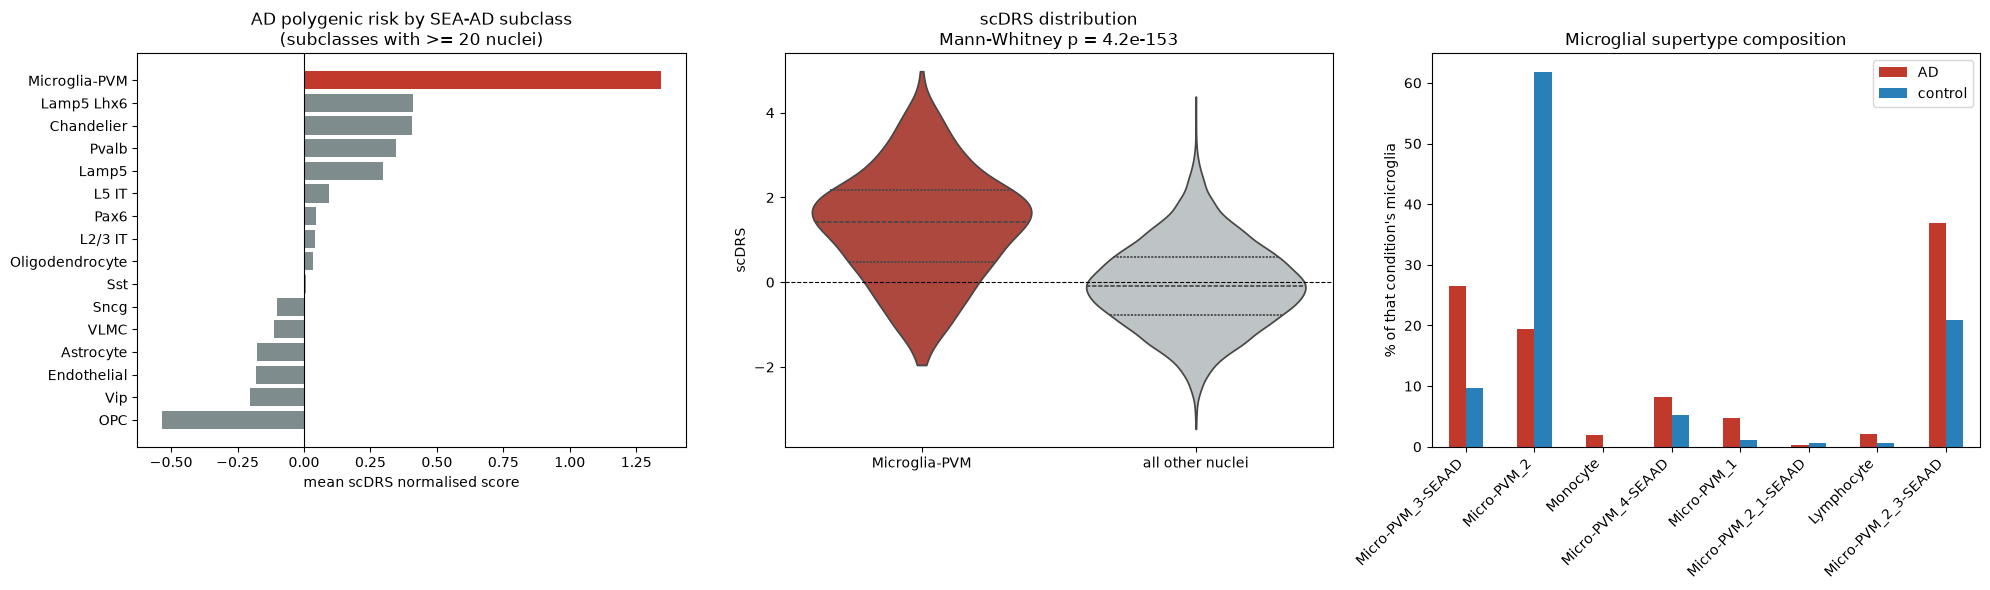

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sub_stats = (group_stats[(group_stats["grouping"] == "mmc_subclass")
                         & (group_stats["n_cell"] >= 20)]
             .sort_values("mean_norm_score"))
axes[0].barh(sub_stats["group"].astype(str), sub_stats["mean_norm_score"],
             color=["#c0392b" if g == "Microglia-PVM" else "#7f8c8d"
                    for g in sub_stats["group"]])
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set(xlabel="mean scDRS normalised score",
            title="AD polygenic risk by SEA-AD subclass\n(subclasses with >= 20 nuclei)")

box = pd.DataFrame({
    "scDRS": np.concatenate([mg_scores.to_numpy(), rest_scores.to_numpy()]),
    "group": ["Microglia-PVM"] * len(mg_scores) + ["all other nuclei"] * len(rest_scores)})
sns.violinplot(data=box, x="group", y="scDRS", hue="group", legend=False, ax=axes[1],
               palette=["#c0392b", "#bdc3c7"], inner="quartile", cut=0)
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].set(xlabel="", title=f"scDRS distribution\nMann-Whitney p = {p_mg:.1e}")

comp = mic_tab[["n_AD", "n_ct"]].astype(float)
comp = comp.div(comp.sum(axis=0), axis=1) * 100
comp.plot(kind="bar", ax=axes[2], color=["#c0392b", "#2980b9"])
axes[2].set(ylabel="% of that condition's microglia", xlabel="",
            title="Microglial supertype composition")
axes[2].legend(["AD", "control"])
axes[2].tick_params(axis="x", rotation=45)
for lbl in axes[2].get_xticklabels():
    lbl.set_ha("right")

plt.tight_layout()
save_fig(fig, "07_mapmycells_summary")
plt.show()

In [14]:
# One master per-nucleus table: author labels, clustering, reference labels, scores
marker_scores = pd.read_csv(INTERIM / "marker_scores.tsv", sep="\t", index_col=0)
cell_meta = obs[["oupSample.batchCond", "oupSample.cellType", "oupSample.subclustID", "leiden",
                 "mmc_class", "mmc_subclass", "mmc_supertype", "mmc_coarse",
                 "mmc_class_prob", "mmc_subclass_prob", "mmc_supertype_prob",
                 "scdrs_norm_score", "scdrs_pval", "scdrs_fdr"]].join(marker_scores)
save_table(cell_meta, "07_cell_metadata")
cell_meta.head(3)

  table -> results/tables/07_cell_metadata.tsv  (13,214 rows x 17 cols, 2672 KB)


,oupSample.batchCond,oupSample.cellType,oupSample.subclustID,leiden,mmc_class,mmc_subclass,mmc_supertype,mmc_coarse,mmc_class_prob,mmc_subclass_prob,mmc_supertype_prob,scdrs_norm_score,scdrs_pval,scdrs_fdr,Mic12_score,Mic13_score,Ast10_score
AAACCTGGTAGAAAGG_AD5_AD6,AD,oligo,o3,0,Non-neuronal and Non-neural,Oligodendrocyte,Oligo_2,oligo,1.0,1.0,0.9999,1.422742,0.081265,0.840905,-0.641936,-0.303103,0.458663
AAACCTGGTAGCGATG_AD5_AD6,AD,oligo,o3,0,Non-neuronal and Non-neural,Oligodendrocyte,Oligo_2,oligo,1.0,1.0,1.0000,0.691384,0.240351,0.972540,1.295772,1.204292,-0.429895
AAACCTGTCAGTCAGT_AD5_AD6,AD,oligo,o3,0,Non-neuronal and Non-neural,Oligodendrocyte,Oligo_4,oligo,1.0,1.0,0.9999,-1.990734,0.981649,0.999942,-0.741288,-0.421783,1.140347
